# 🧠 Tier 1: TF-IDF + Support Vector Machine (SVM) Exploration
This notebook guides you through training and exploring the **Tier 1 Classifier** for BrainDump.AI.

### What we will do:
1. **Environment Setup**: Add root path and load dependencies.
2. **Data Loading & Analysis**: Read training samples and visualize category distributions using matplotlib.
3. **Text Preprocessing**: Inspect how `TextCleaner` processes and lemmatizes short thoughts.
4. **Training the Classifier**: Train TF-IDF + LinearSVC with 80/20 train/test split.
5. **Model Evaluation**: Print a classification report and plot a Confusion Matrix.
6. **Top Keywords Analysis**: Uncover exactly which words/n-grams the SVM associates with each category.
7. **Save & Smoke Test**: Export the final model to `models/tier1_svm.pkl` and test interactive queries.

## 🛠️ Step 1: Environment Setup

In [1]:
import sys
from pathlib import Path

# Add the project root to sys.path so we can import the local ml package
ROOT = Path.cwd().parent if Path.cwd().name == 'training' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project Root directory: {ROOT}")

# Standard imports
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Scikit-learn imports
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import joblib

# Set up matplotlib style
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

Project Root directory: /app


## 📥 Step 2: Load Data & Visualize Class Distributions

Total dataset size: 125 samples

                                                text     label
0  I need to talk to mum about her health appoint...  PERSONAL
1  feeling anxious about meeting new people at th...  PERSONAL
2        journal: grateful for the walk this morning  PERSONAL
3                  call dad this weekend to catch up  PERSONAL
4  I want to read more books this year at least o...  PERSONAL
5           thinking about getting back into the gym  PERSONAL
6  need to fix my sleep schedule it's been terrib...  PERSONAL
7  relationship is feeling distant lately need to...  PERSONAL
8  want to cook more at home and stop eating out ...  PERSONAL
9         feeling burnt out from work need a holiday  PERSONAL


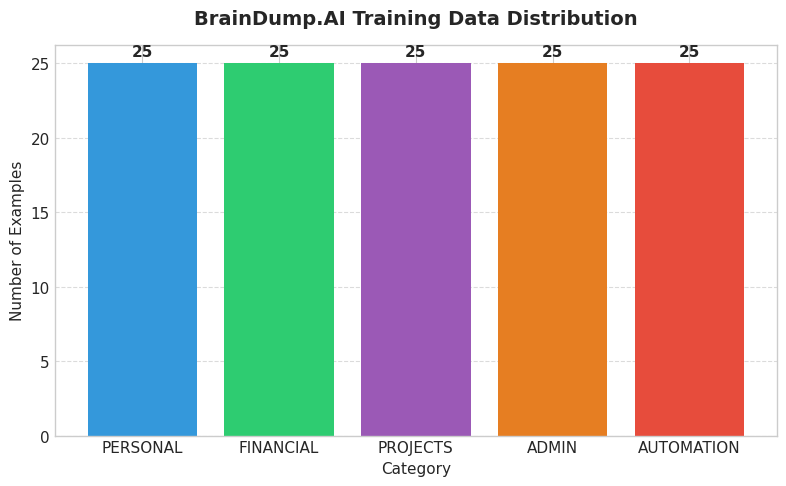

In [2]:
DATA_PATH = ROOT / "training" / "data" / "seed_data.json"
CATEGORIES = ["PERSONAL", "FINANCIAL", "PROJECTS", "ADMIN", "AUTOMATION"]

with open(DATA_PATH, encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
print(f"Total dataset size: {len(df)} samples\n")
print(df.head(10))

# Plot the class distribution
class_counts = df['label'].value_counts()
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.index, class_counts.values, color=colors[:len(class_counts)])
plt.title('BrainDump.AI Training Data Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category')
plt.ylabel('Number of Examples')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{int(yval)}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 🧹 Step 3: Text Preprocessing Demonstration
We import `TextCleaner` to see how it transforms text (lemmatization and noise removal).

In [3]:
from ml.preprocessing.cleaner import TextCleaner
cleaner = TextCleaner()

sample_thoughts = [
    "I'm going to run in the park tomorrow morning",
    "automate the weekly status report using python and a cron job",
    "calculating the monthly budget for housing and grocery bills"
]

print("Sample cleaning transformation:")
print("=" * 60)
for thought in sample_thoughts:
    cleaned = cleaner.clean(thought)
    print(f"Original: {thought}")
    print(f"Cleaned:  {cleaned}")
    print("-" * 60)

# Clean the entire dataset
df['cleaned_text'] = df['text'].apply(cleaner.clean)
print("Dataset cleaned successfully.")

Sample cleaning transformation:
Original: I'm going to run in the park tomorrow morning
Cleaned:  go run park tomorrow morning
------------------------------------------------------------
Original: automate the weekly status report using python and a cron job
Cleaned:  automate weekly status report python cron job
------------------------------------------------------------
Original: calculating the monthly budget for housing and grocery bills
Cleaned:  calculate monthly budget housing grocery bill
------------------------------------------------------------
Dataset cleaned successfully.


## 🤖 Step 4: Split Train/Test and Build Pipeline

In [ ]:
# Stratified split to keep category ratios identical in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['label'],
    test_size=0.20,
    random_state=42,
    stratify=df['label']
)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size:  {len(X_test)} samples")

# Define pipeline with TF-IDF Vectorizer (words + bigrams) and SVM classifier
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),     # unigrams and bigrams
        sublinear_tf=True,      # scale term frequencies log-arithmically
        min_df=1,
        strip_accents="unicode"
    )),
    ("svm", LinearSVC(
        C=1.0, 
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

# Fit model on training partition
pipeline.fit(X_train, y_train)
print("\nModel trained successfully on split subset.")

## 📊 Step 5: Evaluate Model Performance
Let's check precision, recall, and plot a confusion matrix to see if the classes are getting mixed up.

In [ ]:
y_pred = pipeline.predict(X_test)

print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=CATEGORIES, zero_division=0))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=CATEGORIES)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORIES)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.grid(False)
plt.show()

## 🔍 Step 6: Interpretability — What did the SVM learn?
Let's look at the weights (coefficients) assigned by the Linear SVM to see the top features/words for each category.

In [ ]:
vectorizer = pipeline.named_steps['tfidf']
classifier = pipeline.named_steps['svm']
feature_names = np.array(vectorizer.get_feature_names_out())

print("Top 8 features driving predictions for each category:\n")

colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']
plt.figure(figsize=(15, 10))
for i, category in enumerate(classifier.classes_):
    # Get weights for this category class index
    coefs = classifier.coef_[i] if len(classifier.classes_) > 2 else classifier.coef_[0]
    if len(classifier.classes_) == 2 and i == 0:
        coefs = -coefs # binary classification handling
        
    top_indices = np.argsort(coefs)[-8:] # Top 8 positive coefficients
    top_features = feature_names[top_indices]
    top_coefs = coefs[top_indices]
    
    # Print text summary
    print(f"🔹 {category}:")
    features_text = ", ".join([f"{f} ({w:.2f})" for f, w in zip(top_features[::-1], top_coefs[::-1])])
    print(f"   {features_text}\n")
    
    # Subplot plot
    plt.subplot(3, 2, i + 1)
    y_pos = np.arange(len(top_features))
    plt.barh(y_pos, top_coefs, align='center', color=colors[i % len(colors)], alpha=0.8)
    plt.yticks(y_pos, top_features)
    plt.xlabel('Coefficient Weight')
    plt.title(f'Category: {category}', fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 💾 Step 7: Final Retraining & Saving the Model
Now that we know the performance is solid, we retrain the pipeline on 100% of the seed dataset and dump it to `models/tier1_svm.pkl`.

In [ ]:
MODEL_PATH = ROOT / "models" / "tier1_svm.pkl"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"Retraining pipeline on all {len(df)} samples...")
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=1,
        strip_accents="unicode"
    )),
    ("svm", LinearSVC(
        C=1.0,
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

final_pipeline.fit(df['cleaned_text'], df['label'])

# Save model file
joblib.dump(final_pipeline, MODEL_PATH)
print(f"✅ Successfully saved model to {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.1f} KB)")

## 🧪 Step 8: Play with it! (Interactive Evaluation)
Input any thought and watch the model calculate classification categories and decision probabilities.

In [ ]:
def predict_thought(text):
    # Clean input text
    cleaned = cleaner.clean(text)
    
    # Calculate decision scores
    decision_scores = final_pipeline.decision_function([cleaned])[0]
    
    # Softmax conversion
    exp_scores = np.exp(decision_scores - np.max(decision_scores))
    probabilities = exp_scores / exp_scores.sum()
    
    pred_idx = np.argmax(probabilities)
    predicted_class = final_pipeline.classes_[pred_idx]
    confidence = probabilities[pred_idx]
    
    print(f"Original Input: \"{text}\"")
    print(f"Cleaned Input:  \"{cleaned}\"")
    print(f"Prediction:     {predicted_class} ({confidence:.1%})")
    print("-" * 40)
    
    # Plot the probabilities
    fig, ax = plt.subplots(figsize=(6, 3))
    y_pos = np.arange(len(final_pipeline.classes_))
    bars = ax.barh(y_pos, probabilities, align='center', color=['#34495e' if c != predicted_class else '#1abc9c' for c in final_pipeline.classes_])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(final_pipeline.classes_)
    ax.invert_yaxis()  # top-down
    ax.set_xlabel('Probability')
    ax.set_xlim(0, 1.0)
    
    # Annotate bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.1%}', ha='left', va='center', fontweight='bold' if width > 0.3 else 'normal')
        
    plt.tight_layout()
    plt.show()
    print("\n")

# Try a couple of inputs!
predict_thought("need to automate cleaning old files with Python script")
predict_thought("i should probably buy some index funds on interactive brokers next week")
predict_thought("remind me to sign the rental agreement lease")